# CNN Invariance — All Models Combined

Four figures comparing AlexNet, VGG16, and ResNet50:

| | Pooled features | Raw (flattened) features |
|---|---|---|
| **Per-block** (5 blocks) | Figure 1a | Figure 1b |
| **Per-layer/conv** | Figure 2a | Figure 2b |

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

outdir = 'outputs'

# ── Pooled features ──────────────────────────────────────────────────────────
alexnet_block  = np.load(os.path.join(outdir, 'alexnet_inv_per_conv.npy'),     allow_pickle=True).item()
vgg16_block    = np.load(os.path.join(outdir, 'vgg16_inv_per_block.npy'),      allow_pickle=True).item()
resnet_block   = np.load(os.path.join(outdir, 'resnet50_inv_per_block.npy'),   allow_pickle=True).item()

alexnet_conv   = np.load(os.path.join(outdir, 'alexnet_inv_per_conv.npy'),     allow_pickle=True).item()
vgg16_conv     = np.load(os.path.join(outdir, 'vgg16_inv_per_conv.npy'),       allow_pickle=True).item()
resnet_conv    = np.load(os.path.join(outdir, 'resnet50_inv_per_conv.npy'),     allow_pickle=True).item()

# ── Raw (flattened) features ──────────────────────────────────────────────────
alexnet_block_raw = np.load(os.path.join(outdir, 'alexnet_inv_per_conv_raw.npy'),    allow_pickle=True).item()
vgg16_block_raw   = np.load(os.path.join(outdir, 'vgg16_inv_per_block_raw.npy'),     allow_pickle=True).item()
resnet_block_raw  = np.load(os.path.join(outdir, 'resnet50_inv_per_block_raw.npy'),  allow_pickle=True).item()

alexnet_conv_raw  = np.load(os.path.join(outdir, 'alexnet_inv_per_conv_raw.npy'),    allow_pickle=True).item()
vgg16_conv_raw    = np.load(os.path.join(outdir, 'vgg16_inv_per_conv_raw.npy'),      allow_pickle=True).item()
resnet_conv_raw   = np.load(os.path.join(outdir, 'resnet50_inv_per_conv_raw.npy'),   allow_pickle=True).item()

print('Pooled — conv layers:', len(alexnet_conv['layer_names']), len(vgg16_conv['layer_names']), len(resnet_conv['layer_names']))
print('Raw    — conv layers:', len(alexnet_conv_raw['layer_names']), len(vgg16_conv_raw['layer_names']), len(resnet_conv_raw['layer_names']))

Pooled — conv layers: 5 13 49
Raw    — conv layers: 5 13 49


In [5]:
MODELS_BLOCK = [
    {'color': '#e36e2b', 'label': 'AlexNet'},
    {'color': '#e0a917', 'label': 'VGG16'},
    {'color': '#c0394b', 'label': 'ResNet50'},
]

def plot_per_block(ax, datasets, title):
    x = np.arange(5)
    for m, d in zip(MODELS_BLOCK, datasets):
        mean = d['mean']
        std  = d['std']
        ax.plot(x, mean, 'o-', color=m['color'], lw=2, ms=6, label=m['label'])
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=m['color'])
    ax.axhline(0, color='gray', lw=1, linestyle='--')
    ax.set_ylim(-0.1, 0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Block 1', 'Block 2', 'Block 3', 'Block 4', 'Block 5'], fontsize=10)
    ax.set_xlabel('Block')
    ax.set_ylabel('Invariance')
    ax.set_title(title, fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_per_layer(ax, datasets, title):
    for m, d in zip(MODELS_BLOCK, datasets):
        mean = d['mean']
        std  = d['std']
        x    = np.arange(len(mean))
        ax.plot(x, mean, 'o-', color=m['color'], lw=2, ms=4,
                label=f"{m['label']} ({len(mean)} layers)")
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=m['color'])
    ax.axhline(0, color='gray', lw=1, linestyle='--')
    ax.set_ylim(-0.1, 0.7)
    ax.set_xlabel('Layer index')
    ax.set_ylabel('Invariance')
    ax.set_title(title, fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## Figure 1 — Per-block (5 blocks per model)

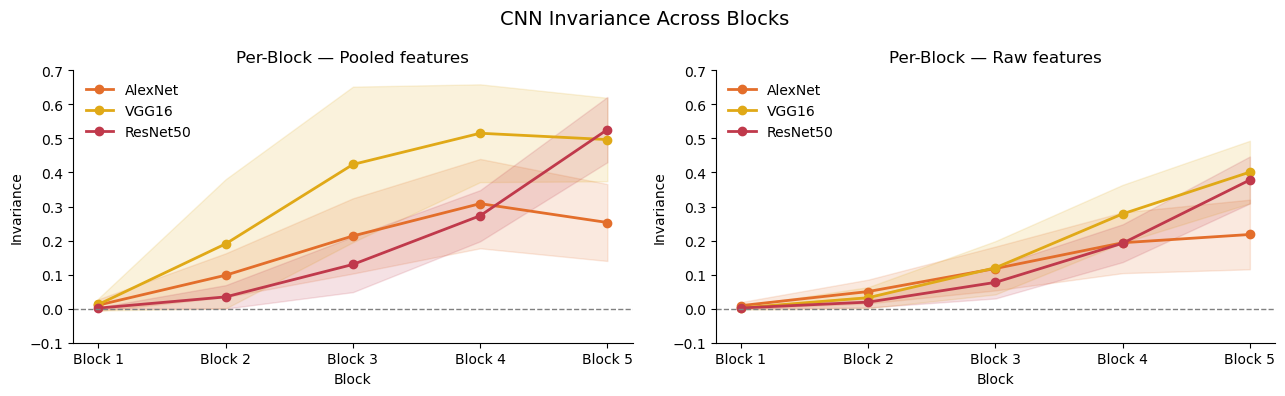

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_per_block(axes[0], [alexnet_block, vgg16_block, resnet_block],
               'Per-Block — Pooled features')
plot_per_block(axes[1], [alexnet_block_raw, vgg16_block_raw, resnet_block_raw],
               'Per-Block — Raw features')

plt.suptitle('CNN Invariance Across Blocks', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/cnn_invariance_block.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2 — Per-layer/conv (original depth)

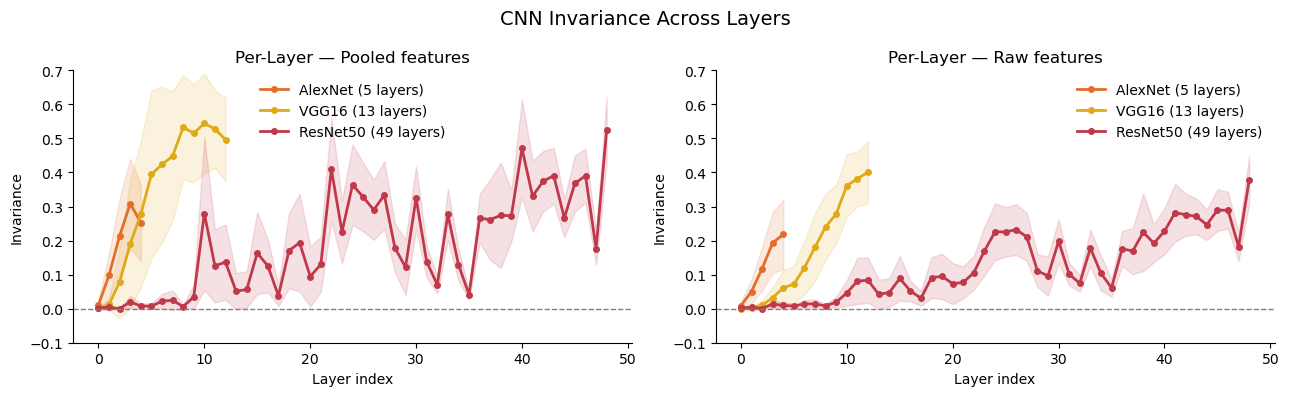

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_per_layer(axes[0], [alexnet_conv, vgg16_conv, resnet_conv],
               'Per-Layer — Pooled features')
plot_per_layer(axes[1], [alexnet_conv_raw, vgg16_conv_raw, resnet_conv_raw],
               'Per-Layer — Raw features')

plt.suptitle('CNN Invariance Across Layers', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/cnn_invariance_layer.png', dpi=300, bbox_inches='tight')
plt.show()